<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/Quantifying_Output_Uncertainty_with_Monte_Carlo_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **독립적인 무작위 변화량($\epsilon_t$)을 누적(Cumulative Sum)** 하여 다음 단계가 이전 단계에 의해서만 결정되는 경로를 생성하므로, 가장 단순하고 기본적인 형태의 무작위 행보(Random Walk) 시뮬레이션

#### **1. A drunken man walking with 정규분포**

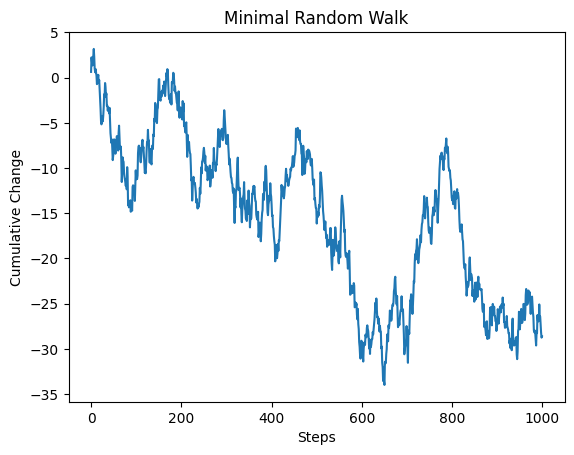

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 100개의 무작위 변화량(shock)을 생성하고, 누적 합을 계산하여 경로를 만듭니다. (시작점 0)
path = np.cumsum(np.random.normal(0, 1, 1000))

# 2. 시각화
plt.plot(path)
plt.title("Minimal Random Walk")
plt.xlabel("Steps")
plt.ylabel("Cumulative Change")
plt.show()


#### **2. A drunken man walking with 이항분포(전진/후진)**

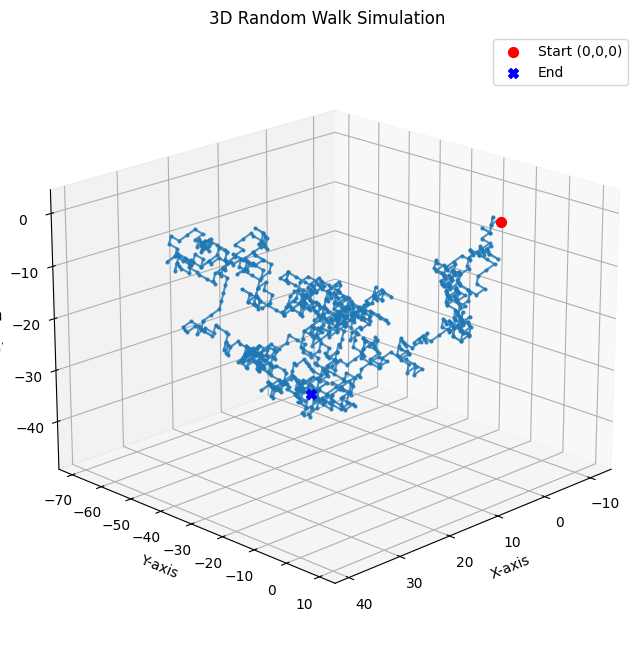

3차원 무작위 행보 시뮬레이션이 1000 단계로 완료되었습니다.
최종 위치: (0, -60, -46)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 시뮬레이션 설정
NUM_STEPS = 1000  # 무작위 행보 단계 수

# 1. 3차원 무작위 변화량 생성 (각 단계에서 x, y, z 방향의 변화)
# 각 단계마다 -1 또는 1의 값을 가질 수 있도록 합니다. (간단한 예)
# 더 복잡한 변화량을 원하면 np.random.normal 등을 사용할 수 있습니다.

steps = np.random.choice([-1, 1], size=(NUM_STEPS, 3))  # 주사위 던지기 +0.5, -0.5 걷기

# 2. 누적 합을 계산하여 3차원 경로 생성 (시작점 0,0,0)
# np.cumsum은 axis=0 방향으로 누적 합을 계산합니다.
path = np.cumsum(steps, axis=0)

# 시작점 (0,0,0)을 경로에 추가
path = np.vstack([[0, 0, 0], path])

# 3. 시각화
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# 경로 플롯
ax.plot(path[:, 0], path[:, 1], path[:, 2], linestyle='-', marker='o', markersize=2, alpha=0.8)

# 시작점과 끝점 표시
ax.scatter(path[0, 0], path[0, 1], path[0, 2], c='red', marker='o', s=50, label='Start (0,0,0)')
ax.scatter(path[-1, 0], path[-1, 1], path[-1, 2], c='blue', marker='X', s=50, label='End')

# 축 레이블 설정
ax.set_title("3D Random Walk Simulation")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

# 그리드 표시
ax.grid(True, linestyle=':', alpha=0.3)

# 범례 표시
ax.legend()

# 뷰 각도 조절 (선택 사항)
ax.view_init(elev=20, azim=45) # elev: 수직 각도, azim: 수평 각도

plt.show()

print(f"3차원 무작위 행보 시뮬레이션이 {NUM_STEPS} 단계로 완료되었습니다.")
print(f"최종 위치: ({path[-1, 0]}, {path[-1, 1]}, {path[-1, 2]})")

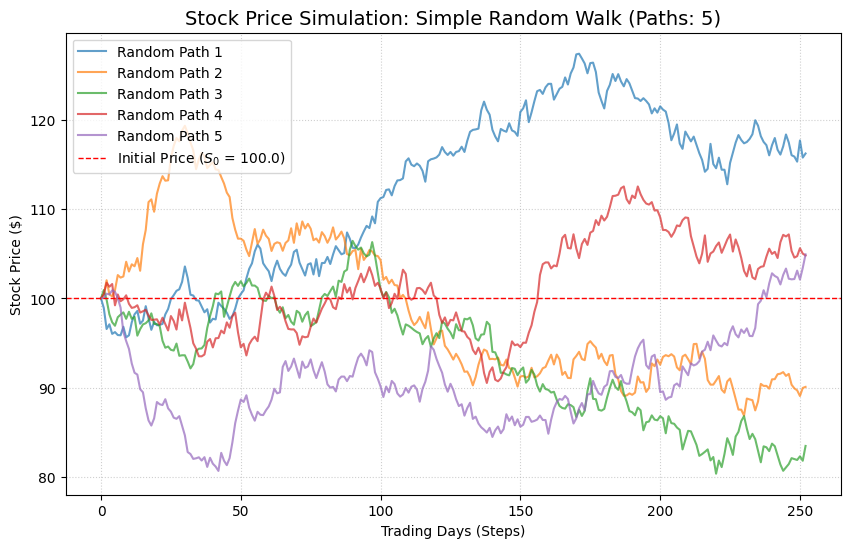

시뮬레이션 결과: 5개의 무작위 행보 경로가 생성되었습니다.
주가 경로는 평균이 0인 무작위 충격에 의해 결정되며, 미래를 예측하기 어렵다는 Random Walk 가정을 시각적으로 보여줍니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 시뮬레이션 설정
S0 = 100.0        # 초기 주가 (Starting Price)
DAYS = 252        # 시뮬레이션 기간 (1년 거래일 수)
NUM_PATHS = 5     # 시뮬레이션할 경로의 수

# 1. 주가 경로 생성 함수 (Simple Random Walk Model)
def simple_random_walk(S0, days, num_paths):
    """
    주가가 이전 가격에 무작위적인 변화(Random Shock)를 더해 결정되는
    단순 무작위 행보 모델을 시뮬레이션합니다.
    """
    # 일일 변화량 (Random Shock) 생성
    # 평균 0, 표준편차 1인 정규 분포의 무작위 값 사용
    # 크기: (경로 수, 일 수)
    shocks = np.random.normal(loc=0, scale=1, size=(num_paths, days))

    # 누적 변화량 계산
    # 각 일일 변화량을 누적하여 경로를 만듭니다.
    price_changes = np.cumsum(shocks, axis=1)

    # 초기 주가(S0)를 더하여 최종 주가 경로 배열 생성
    # S(t) = S0 + Cumulative Sum of Shocks
    price_paths = S0 + price_changes

    # 초기 주가 (t=0)를 포함시키기 위해 맨 앞에 S0 열을 추가
    # 초기값(S0) 배열 생성: 크기 (num_paths, 1)
    S0_col = np.full((num_paths, 1), S0)

    # S0와 price_paths를 가로로 결합
    full_paths = np.hstack((S0_col, price_paths))

    return full_paths

# 2. 시뮬레이션 실행
random_walk_paths = simple_random_walk(S0, DAYS, NUM_PATHS)

# 3. 시각화
plt.figure(figsize=(10, 6))
time_index = np.arange(DAYS + 1) # 시간축 (0일부터 252일까지)

for i in range(NUM_PATHS):
    plt.plot(time_index, random_walk_paths[i], alpha=0.7,
             label=f'Random Path {i+1}', linewidth=1.5)

plt.title(f"Stock Price Simulation: Simple Random Walk (Paths: {NUM_PATHS})", fontsize=14)
plt.xlabel("Trading Days (Steps)")
plt.ylabel("Stock Price ($)")
plt.axhline(S0, color='red', linestyle='--', linewidth=1, label=f'Initial Price ($S_0$ = {S0})')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"시뮬레이션 결과: {NUM_PATHS}개의 무작위 행보 경로가 생성되었습니다.")
print("주가 경로는 평균이 0인 무작위 충격에 의해 결정되며, 미래를 예측하기 어렵다는 Random Walk 가정을 시각적으로 보여줍니다.")

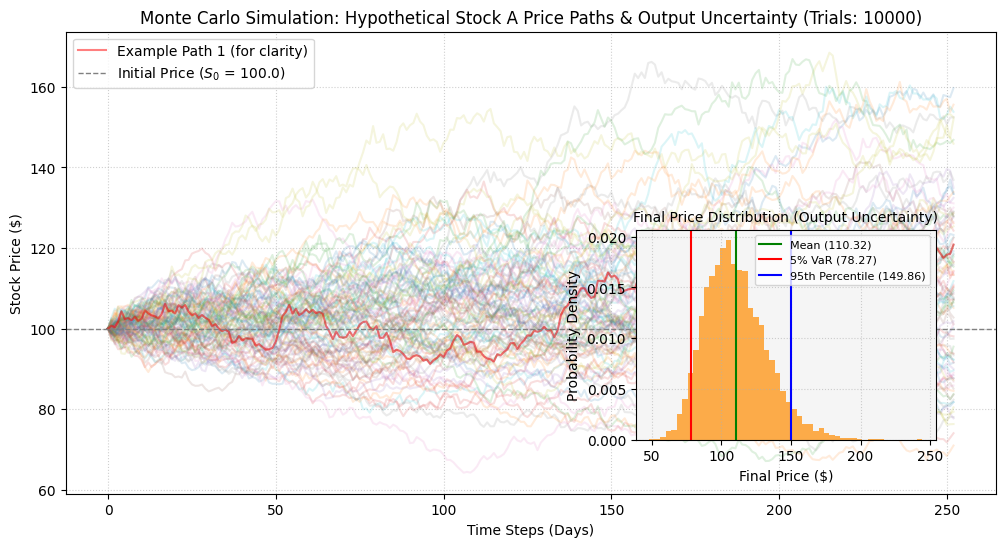


몬테카를로 시뮬레이션 결과 (예측 기간 1년 후):
- 시뮬레이션 평균 주가 (기대값): $110.32
- 5% VaR (최악의 시나리오): $78.27
- 95% 신뢰구간 상한: $149.86
해석: 95% 확률로 주가는 최소 $78.27 이상이 될 것입니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 시뮬레이션 설정
TICKER = "Hypothetical Stock A"
S0 = 100.0        # 초기 주가 (S0)
T = 1             # 예측 기간 (년)
NUM_STEPS = 252   # 시뮬레이션 단계 수 (1년=252 거래일)
NUM_SIMULATIONS = 10000  # 몬테카를로 시뮬레이션 횟수

# GBM 모델 매개변수 (과거 데이터를 기반으로 추정되었다고 가정)
MU = 0.10         # 연간 기대 수익률 (Drift, mu)
SIGMA = 0.20      # 연간 변동성 (Volatility, sigma)

def run_monte_carlo_simulation(S0, mu, sigma, T, num_steps, num_simulations):
    """
    기하 브라운 운동(GBM) 모델을 사용하여 몬테카를로 시뮬레이션을 수행합니다.
    """
    dt = T / num_steps  # 시간 간격

    # 누적 수익률(Z) 계산을 위한 무작위 행렬 생성
    # 행: 시뮬레이션 횟수, 열: 시간 단계
    # (T/num_steps)에 해당하는 정규 분포 무작위 값 사용
    # *Note: 정규 분포 (loc=0, scale=1)는 기본값으로 사용됨
    Z = np.random.standard_normal((num_simulations, num_steps))

    # 시간 t에서의 주가 변화율 계산 (GBM의 이산 근사식 사용)
    # dS/S = mu*dt + sigma*dW
    # dW = sqrt(dt) * Z (위너 프로세스 증분)
    daily_returns = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

    # 주가 경로 계산 (S(t) = S0 * cumulative product of daily returns)
    price_paths = np.zeros((num_simulations, num_steps + 1))
    price_paths[:, 0] = S0

    for t in range(1, num_steps + 1):
        price_paths[:, t] = price_paths[:, t-1] * daily_returns[:, t-1]

    # 최종 주가 (예측 기간 T 후)
    final_prices = price_paths[:, -1]

    return price_paths, final_prices

# 1. 시뮬레이션 실행
price_paths, final_prices = run_monte_carlo_simulation(S0, MU, SIGMA, T, NUM_STEPS, NUM_SIMULATIONS)

# 2. 결과 분석 및 불확실성 정량화
mean_price = np.mean(final_prices)
median_price = np.median(final_prices)

# 불확실성 범위 (신뢰구간 또는 리스크 값) 정량화
# 5% VaR (최악의 5% 시나리오 중 가장 좋은 값)
var_5 = np.percentile(final_prices, 5)
# 95% 신뢰구간 상한 (최고의 5% 시나리오 직전 값)
percentile_95 = np.percentile(final_prices, 95)

# 3. 시각화
plt.figure(figsize=(12, 6))

# A. 주가 경로 플롯 (일부만)
num_display_paths = 100
plt.plot(price_paths[:num_display_paths].T, alpha=0.15)
plt.plot(price_paths[0].T, color='red', label='Example Path 1 (for clarity)', alpha=0.5)
plt.axhline(S0, color='gray', linestyle='--', linewidth=1, label=f'Initial Price ($S_0$ = {S0})')

# B. 최종 분포를 히스토그램으로 시각화 (불확실성 정량화)
plt.title(f"Monte Carlo Simulation: {TICKER} Price Paths & Output Uncertainty (Trials: {NUM_SIMULATIONS})")
plt.xlabel("Time Steps (Days)")
plt.ylabel("Stock Price ($)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

# 최종 가격 분포 (Output Uncertainty)를 작은 플롯에 추가
ax2 = plt.axes([0.6, 0.2, 0.25, 0.35], facecolor='whitesmoke') # 임베디드 플롯 위치 설정
ax2.hist(final_prices, bins=50, density=True, color='darkorange', alpha=0.7)
ax2.axvline(mean_price, color='green', linestyle='-', linewidth=1.5, label=f'Mean ({mean_price:.2f})')
ax2.axvline(var_5, color='red', linestyle='-', linewidth=1.5, label=f'5% VaR ({var_5:.2f})')
ax2.axvline(percentile_95, color='blue', linestyle='-', linewidth=1.5, label=f'95th Percentile ({percentile_95:.2f})')

ax2.set_title("Final Price Distribution (Output Uncertainty)", fontsize=10)
ax2.set_xlabel("Final Price ($)")
ax2.set_ylabel("Probability Density")
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.show()

# 최종 불확실성 분석 결과 출력
print("\n" + "="*50)
print(f"몬테카를로 시뮬레이션 결과 (예측 기간 {T}년 후):")
print(f"- 시뮬레이션 평균 주가 (기대값): ${mean_price:.2f}")
print(f"- 5% VaR (최악의 시나리오): ${var_5:.2f}")
print(f"- 95% 신뢰구간 상한: ${percentile_95:.2f}")
print("="*50)
print("해석: 95% 확률로 주가는 최소 ${:.2f} 이상이 될 것입니다.".format(var_5))

<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-335256640.py:59: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Monte Carlo Simulation to Estimate $\pi$\nEstimated $\pi$: {pi_estimate:.6f} (N={N})')
/tmp/ipython-input-335256640.py:71: SyntaxWarning: invalid escape sequence '\p'
  print(f"추정된 $\pi$: {pi_estimate}")


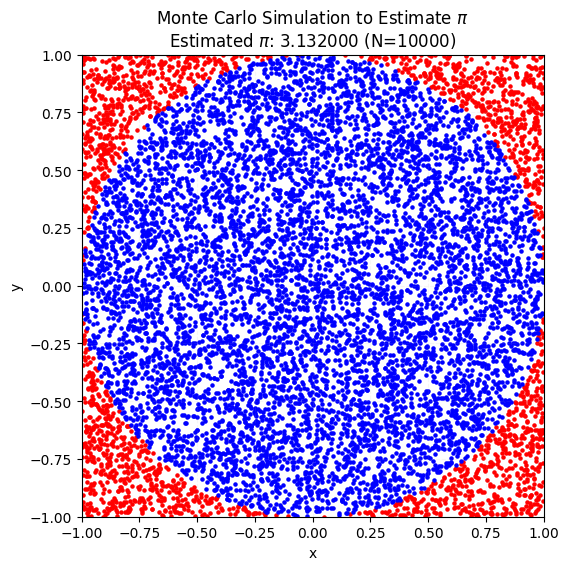

총 점 개수 (N): 10000
원 안의 점 개수: 7830
추정된 $\pi$: 3.132


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 시뮬레이션 설정 ---
N = 10000 # 던질 점의 총 개수 (시뮬레이션 정밀도)

# 사각형과 원 안에 들어간 점의 개수를 셀 변수
n_circle = 0
n_total = N

# 결과를 저장할 리스트
x_inside = []
y_inside = []
x_outside = []
y_outside = []

# --- 몬테카를로 시뮬레이션 실행 ---
for _ in range(N):
    # -1.0과 1.0 사이의 임의의 x, y 좌표 생성 (정사각형 범위)
    x = random.uniform(-1.0, 1.0)
    y = random.uniform(-1.0, 1.0)

    # 원의 중심 (0, 0)에서 점까지의 거리의 제곱 계산
    # 원의 방정식: x^2 + y^2 = r^2. 여기서는 r=1 이므로 x^2 + y^2 = 1
    distance_squared = x**2 + y**2

    # 거리가 1보다 작거나 같으면 원 안에 있음
    if distance_squared <= 1.0:
        n_circle += 1
        x_inside.append(x)
        y_inside.append(y)
    else:
        x_outside.append(x)
        y_outside.append(y)

# --- 파이(pi) 값 추정 ---
# 사각형 넓이 : (2 * 2) = 4
# 원 넓이 : pi * r^2 = pi * 1^2 = pi
# (원 안의 점 개수) / (총 점 개수) ≈ (원 넓이) / (사각형 넓이)
# n_circle / N ≈ pi / 4
pi_estimate = 4 * (n_circle / n_total)

# --- 결과 시각화 ---
plt.figure(figsize=(6, 6))

# 원 밖에 있는 점들 (빨간색)
plt.scatter(x_outside, y_outside, color='red', s=5, label='Outside Circle')

# 원 안에 있는 점들 (파란색)
plt.scatter(x_inside, y_inside, color='blue', s=5, label='Inside Circle')

# 플롯 범위 설정 (-1.0부터 1.0까지)
plt.xlim(-1.0, 1.0)
plt.ylim(-1.0, 1.0)
plt.gca().set_aspect('equal', adjustable='box') # x, y 축 비율을 같게 설정

# 제목 및 라벨 추가
plt.title(f'Monte Carlo Simulation to Estimate $\pi$\nEstimated $\pi$: {pi_estimate:.6f} (N={N})')
plt.xlabel('x')
plt.ylabel('y')

# 그리드 추가
plt.grid(True, linestyle='--', alpha=0.1)

# 시각화 보여주기
plt.show()

print(f"총 점 개수 (N): {n_total}")
print(f"원 안의 점 개수: {n_circle}")
print(f"추정된 $\pi$: {pi_estimate}")

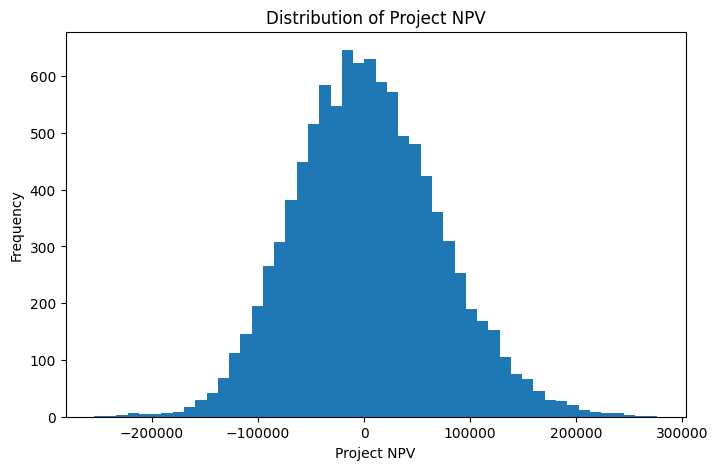

--- NPV 분석 결과 ---
            NPV
count   10000.0
mean     3656.0
std     68334.0
min   -254764.0
25%    -43953.0
50%      1034.0
75%     48195.0
max    276515.0

There is a 50% probability that the project will have a positive NPV.


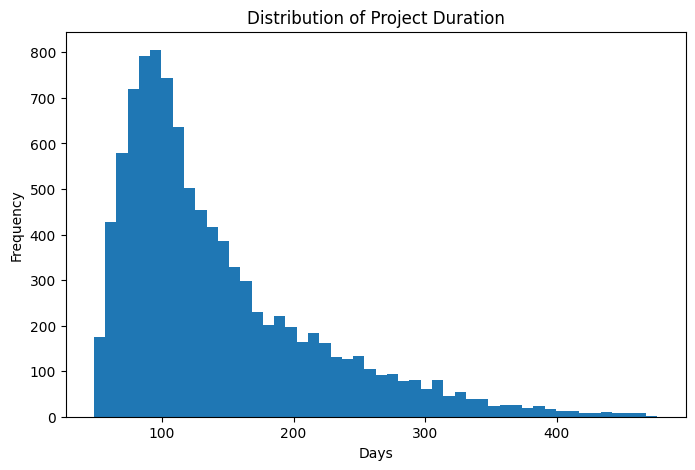


--- 프로젝트 기간 분석 결과 ---
          Days
count  10000.0
mean     143.0
std       75.0
min       48.0
25%       89.0
50%      119.0
75%      177.0
max      477.0


In [ ]:
from datetime import datetime
from numpy import random as npr

# Specify model constants per full-time equivalent (fte)
daily_rate = 400
technology_charges = 500
overhead_charges = 200
# Specify other constants
tax_rate = 0.15
# Specify model risk factors that have little or no correlation among them.
# Number of trials/simulations
n = 10000
# Number of full-time equivalent persons on the team
fte = npr.uniform(low=1, high=5, size=n)
# In person days and driven independently by the scope of the project
effort = npr.uniform(low=240, high=480, size=n)
# Based on market research or expert judgment or both
price = npr.uniform(low=100, high=200, size=n)
# Independent of price in the price range considered
units = npr.normal(loc=1000, scale=500, size=n)
# Discount rate for the project period based on risk of similar efforts
discount_rate = npr.uniform(low=0.06, high=0.10, size=n)
# Specify how risk factors affect the project model
labor_costs = effort * daily_rate
technology_costs = fte * technology_charges
overhead_costs = fte * overhead_charges
revenues = price * units
# Duration determines the number of days the project will take to complete
# assuming no interruption. Different from the elapsed time of the project.
duration = effort/fte
# Specify target_value
free_cash_flow = (revenues - labor_costs - technology_costs - overhead_costs) * (1 - tax_rate)
# Simulate project NPV assuming initial FCF=0
npv = free_cash_flow / (1 + discount_rate)
# Convert numpy array to pandas DataFrame for easier analysis
NPV = pd.DataFrame(npv, columns=['NPV'])
# Estimate project duration in days
Duration = pd.DataFrame(duration, columns=['Days'])

# --- Plot histogram of NPV distribution (수정된 플로팅 방식) ---
plt.figure(figsize=(8, 5))
plt.hist(NPV['NPV'], bins=50)
plt.title('Distribution of Project NPV')
plt.xlabel('Project NPV')
plt.ylabel('Frequency')
plt.show()

print("--- NPV 분석 결과 ---")
print(NPV.describe().round())

# Calculate and print success probability
success_probability = sum(NPV['NPV'] > 0)/n * 100
print('\nThere is a {0}% probability that the project will have a positive NPV.'
.format(round(success_probability)))

# --- Plot histogram of project duration distribution (수정된 플로팅 방식) ---
plt.figure(figsize=(8, 5))
plt.hist(Duration['Days'], bins=50)
plt.title('Distribution of Project Duration')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

print("\n--- 프로젝트 기간 분석 결과 ---")
print(Duration.describe().round())
